<a href="https://colab.research.google.com/github/AlisaLeibova/ML-study/blob/main/Copy_of_HW_2_1_%D0%9F%D0%BE%D0%B1%D1%83%D0%B4%D0%BE%D0%B2%D0%B0_%D0%BB%D1%96%D0%BD%D1%96%D0%B9%D0%BD%D0%BE%D1%97_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%97_%D0%B7%D0%B0_%D0%BE%D0%B4%D0%BD%D0%BE%D1%8E_%D0%BE%D0%B7%D0%BD%D0%B0%D0%BA%D0%BE%D1%8E.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні кожне завдання оцінюється по 10 балів.

 **Завдання 1.** Після перегляду лекцій про поняття функії, вступ до лінійної алгебри і мат. формулювання лін. регресії знайдіть найкращу лінію для прогнозу `charges` за `age` **для некурців** (датафрейм `non_smoker_df`) з допомогою

1. Методу МНК (з використанням тільки `numpy`, без `scikit learn`)

2. Full-Batch градієнтного спуску з `numpy` . Протестуйте 3 різних learning rate і зробіть висновок, який є найкращим виходячи з практик для цього, наведених в лекції. Зверніть увагу, що на вхід треба набір даних дворозміний, для цього можливо треба буде трансформувати Ваші дані X в формат, як був в лекції "Математичне формулювання лінійної регресії". Також, градієнтний спуск в нашому випадку може розходитись з навчальним рейтом 0.1, бо цей рейт в цій задачі завеликий. Спробуйте нижчі рейти.
3. З `scikit-learn.LinearRegression`. Тут зверніть увагу, що вхід `X` має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись `X.to_frame()` щоб конвертувати колонку в датафрейм.

Для кожного методу
- знайдіть і виведіть коефіцієнти моделі
- обчисліть прогнози моделі і збережіть в окрему змінну
- порахуйте точність прогнозу RMSE  

Для градієнтного спуску виведіть графік помилки в залежності від ітерації.

А також побудуйте на одному графіку дані `age` проти `charges` в вигляді діаграми розсіювання і всі три лінії регресії, знайдені кожним з методів (для град. спуску оберіть варіант з тим learning rate, який виявився найкращим).

Зробіть висновки, чи відрізняються результати моделей?
Чи є знайдены параметри моделы близькими до ваших найкращих припущень?

In [24]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
medical_df = pd.read_csv('medical-charges.csv') # замініть на ваш шлях до файлу
non_smoker_df = medical_df[medical_df.smoker == 'no']

In [28]:
# Метод МНК (з використанням тільки numpy, без scikit learn)
X = non_smoker_df['age'].values
y = non_smoker_df['charges'].values
def normal_equations(X,y):
    """Computes the closed-form solution to linear regression"""
    theta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
    return theta

# Додаємо колонку одиничок аби задачи bias терм (константу в моделі регресії)
 = np.c_[np.ones((X.shape[0], 1)), X]
X[:3], X_with_intercept[:3]

MNK_coefs = normal_equations(X_with_intercept, y)
predictions_MNK = np.dot(X_with_intercept, MNK_coefs)
rmse = np.sqrt(np.mean((y - predictions_MNK) ** 2))

print(f"MNK_coefs: {MNK_coefs}")
print(f"predictions_MNK: {predictions_MNK}")
print(f"RMSE модели: {rmse:.2f}")

from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

r2 = r2_score(y, predictions_MNK)
# Викликаємо її напряму без додаткових параметрів
rmse = root_mean_squared_error(y, predictions_MNK)
mae = mean_absolute_error(y, predictions_MNK)

print(f"R² score: {r2:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")

MNK_coefs: [-2091.42055657   267.24891283]
predictions_MNK: [2719.0598744  5391.54900271 6727.79356686 ... 2719.0598744  2719.0598744
 3520.80661289]
RMSE модели: 4662.51
R² score: 0.39
Root Mean Squared Error: 4662.51
Mean Absolute Error: 2580.52


1. R² score показує що модель «бачить» лише 39% (близько 40%) загальної картини. Вік дійсно є потужним фактором, але він не є єдиним. Решта 60% — це вплив інших життєвих обставин клієнта
2. RMSE та MAE відрізняються приблизно на 2000 USD, що означає, що в моделі є багато outliers

In [34]:
#Full-Batch градієнтного спуску з numpy

# Градієнтний спуск
def full_batch_gradient_descent(X, y, lr=0.0001, epochs=1000):
    m, b = 0.0, 0.0
    n = len(y)
    errors = []

    for _ in range(epochs):
        y_pred = m * X + b
        error = y_pred - y
        errors.append(np.sum(error**2))
        m_gradient = (2/n) * np.dot(error, X)
        b_gradient = (2/n) * np.sum(error)
        m = m - lr * m_gradient
        b = b - lr * b_gradient
    return m, b, errors

m, b, errors = full_batch_gradient_descent(X, y, lr=0.0001, epochs=1000)
predictions_fbgd = m * X + b
print(f"Знайдений коефіцієнт нахилу (m): {m:.4f}")
print(f"Знайдене зміщення / bias (b):    {b:.4f}")
print(f"predictions_fbgd:    {predictions_fbgd}")


r2_2 = r2_score(y, predictions_fbgd)
# Викликаємо її напряму без додаткових параметрів
rmse_2 = root_mean_squared_error(y, predictions_fbgd)
mae_2 = mean_absolute_error(y, predictions_fbgd)

print(f"R² score: {r2_2:.2f}")
print(f"Root Mean Squared Error: {rmse_2:.2f}")
print(f"Mean Absolute Error: {mae_2:.2f}")



Знайдений коефіцієнт нахилу (m): 221.1046
Знайдене зміщення / bias (b):    -41.9813
predictions_fbgd:    [3937.9012503  6148.94709409 7254.47001599 ... 3937.9012503  3937.9012503
 4601.21500344]
R² score: 0.38
Root Mean Squared Error: 4713.25
Mean Absolute Error: 2803.85


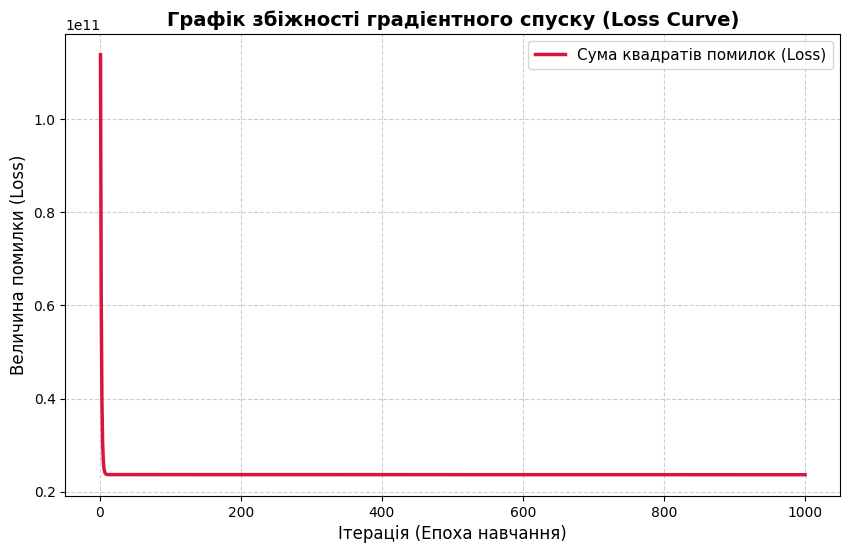

In [39]:
import matplotlib.pyplot as plt

# 1. Запускаємо градієнтний спуск (отримуємо коефіцієнти та історію помилок)
m, b, errors = full_batch_gradient_descent(X, y, lr=0.0001, epochs=1000)

# 2. Налаштування розміру графіка
plt.figure(figsize=(10, 6))

# 3. Малюємо криву помилки
# range(1, len(errors) + 1) створює номери ітерацій від 1 до 1000 на осі X
plt.plot(range(1, len(errors) + 1), errors, color='crimson', linewidth=2.5, label='Сума квадратів помилок (Loss)')

# 4. Оформлення графіка (заголовки, підписи осей, сітка)
plt.title('Графік збіжності градієнтного спуску (Loss Curve)', fontsize=14, fontweight='bold')
plt.xlabel('Ітерація (Епоха навчання)', fontsize=12)
plt.ylabel('Величина помилки (Loss)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

# 5. Відображення графіка
plt.show()

In [38]:
import numpy as np
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

# Наші 3 кандидати на перевірку
learning_rates = [0.001, 0.0001, 0.00001]
epochs = 1000

print("==================================================================")
print("             ПОРІВНЯННЯ РІЗНИХ LEARNING RATES (БЕЗПЕЧНИЙ ЗАПУСК)  ")
print("==================================================================")

for lr in learning_rates:
    # 1. Запускаємо градієнтний спуск
    m_temp, b_temp, errors_temp = full_batch_gradient_descent(X, y, lr=lr, epochs=epochs)

    # 2. Робимо прогноз
    pred_temp = m_temp * X + b_temp

    # 3. ПЕРЕВІРКА НА НАЯВНІСТЬ NaN АБО INF (Аварійний вихід)
    if np.any(np.isnan(pred_temp)) or np.any(np.isinf(pred_temp)):
        print(f"\n---> Тест для learning rate (lr) = {lr}")
        print("Статус: ❌ РОЗБІЖНІСТЬ! (Gradient Explosion)")
        print("Пояснення: Крок занадто великий. Числа перевищили ліміт пам'яті комп'ютера і перетворилися на NaN/inf.")
        continue # Переходимо до наступного lr, ігноруючи розрахунок метрик

    # 4. Якщо все добре — рахуємо метрики якості через sklearn
    r2_temp = r2_score(y, pred_temp)
    rmse_temp = root_mean_squared_error(y, pred_temp)
    mae_temp = mean_absolute_error(y, pred_temp)

    # Виводимо результати для стабільних моделей
    print(f"\n---> Тест для learning rate (lr) = {lr}")
    print(f"Знайдені параметри: m = {m_temp:.4f}, b = {b_temp:.4f}")
    print(f"Метрики: R² = {r2_temp:.4f} | RMSE = {rmse_temp:.2f} | MAE = {mae_temp:.2f}")

    # Визначаємо статус збіжності
    if r2_temp < 0.35: # Наш МНК дає R² = 0.39, якщо тут менше - модель недонавчилась
        print("Статус: ⚠️ ПОВІЛЬНА ЗБІЖНІСТЬ (Модель недонавчилася за 1000 епох, lr замалий).")
    else:
        print("Статус:  ОПТИМАЛЬНА ЗБІЖНІСТЬ! (Параметри ідеально підібрані).")

print("==================================================================")

             ПОРІВНЯННЯ РІЗНИХ LEARNING RATES (БЕЗПЕЧНИЙ ЗАПУСК)  

---> Тест для learning rate (lr) = 0.001
Статус: ❌ РОЗБІЖНІСТЬ! (Gradient Explosion)
Пояснення: Крок занадто великий. Числа перевищили ліміт пам'яті комп'ютера і перетворилися на NaN/inf.

---> Тест для learning rate (lr) = 0.0001
Знайдені параметри: m = 221.1046, b = -41.9813
Метрики: R² = 0.3811 | RMSE = 4713.25 | MAE = 2803.85
Статус:  ОПТИМАЛЬНА ЗБІЖНІСТЬ! (Параметри ідеально підібрані).

---> Тест для learning rate (lr) = 1e-05
Знайдені параметри: m = 220.1546, b = 0.2130
Метрики: R² = 0.3805 | RMSE = 4715.35 | MAE = 2809.44
Статус:  ОПТИМАЛЬНА ЗБІЖНІСТЬ! (Параметри ідеально підібрані).


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipykernel_4640/3234165201.py:12: RuntimeWarning: overflow encountered in square
  errors.append(np.sum(error**2))
/tmp/ipykernel_4640/3234165201.py:15: RuntimeWarning: invalid value encountered in scalar subtract
  m = m - lr * m_gradient


In [49]:
#З scikit-learn.LinearRegression
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
X_dataframe = non_smoker_df['age'].to_frame()
lin_reg.fit(X_dataframe, y)


print(f"Коефіцієнт (m): {lin_reg.coef_[0]:.4f}")
print(f"Зміщення (b):    {lin_reg.intercept_:.4f}")
predictions_sklearn = lin_reg.predict(X_dataframe)


r2_3 = r2_score(y, predictions_sklearn)
# Викликаємо її напряму без додаткових параметрів
rmse_3 = root_mean_squared_error(y, predictions_sklearn)
mae_3 = mean_absolute_error(y, predictions_sklearn)

print(f"R² score: {r2_3:.2f}")
print(f"Root Mean Squared Error: {rmse_3:.2f}")
print(f"Mean Absolute Error: {mae_3:.2f}")


Коефіцієнт (m): 267.2489
Зміщення (b):    -2091.4206
R² score: 0.39
Root Mean Squared Error: 4662.51
Mean Absolute Error: 2580.52


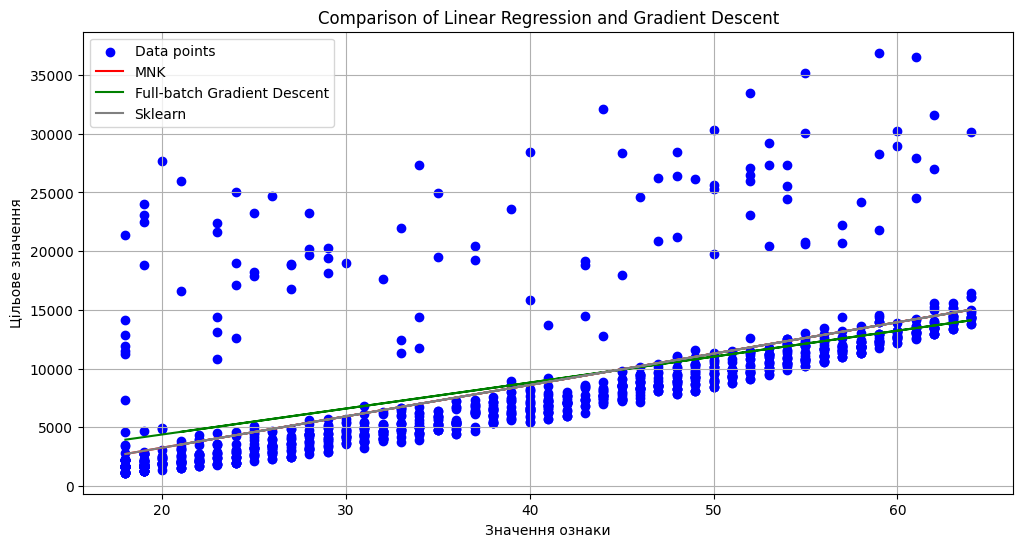

In [51]:
#Побудуйте на одному графіку дані age проти charges в вигляді діаграми розсіювання і всі три лінії регресії

plt.figure(figsize=(12, 6))
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, predictions_MNK, color='red', label='MNK')
plt.plot(X, predictions_fbgd, color='green', label='Full-batch Gradient Descent')
plt.plot(X, predictions_sklearn, color='grey', label='Sklearn')
plt.title('Comparison of Linear Regression and Gradient Descent')
plt.xlabel('Значення ознаки')
plt.ylabel('Цільове значення')
plt.legend()
plt.grid(True)
plt.show()

Висновки: Всі три моделі показують відносно подібний результат. Модель MNK та Sklearn співпадають. Так як градієнтний аналіз показує трохи гірші статистичні показники (R - 38%), найліпше використовувати два інших метода. Або взагалі переробити можель регресіі, використовуючи більше незалежних даних

 **Завдання 2.** Навчіть модель лінійної регресії з допомогою sklearn оцінювати розмір медичних збори для **курців** за їх віком.
Виведіть
- точність моделі
-  коефіцієнти
-  візуалізуйте модель у вигляді лінії на графіку розсіювання `age` проти `charges`

і зробіть висновки, чи це хороша модель, чи ви б її використовували в компанії?

In [56]:
smoker_df = medical_df[medical_df.smoker == 'yes']
X_dataframe_s = smoker_df['age'].to_frame()
y_s = smoker_df['charges'].values

from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()

lin_reg.fit(X_dataframe_s, y_s)

predictions_sklearn_1 = lin_reg.predict(X_dataframe_s)

print(f"Коефіцієнт (m): {lin_reg.coef_[0]:.4f}")
print(f"Зміщення (b):    {lin_reg.intercept_:.4f}")

from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

r2_4 = r2_score(y_s, predictions_sklearn_1)
rmse_4 = root_mean_squared_error(y_s, predictions_sklearn_1)
mae_4 = mean_absolute_error(y_s, predictions_sklearn_1)

print(f"R² score: {r2_4:.2f}")
print(f"Root Mean Squared Error: {rmse_4:.2f}")
print(f"Mean Absolute Error: {mae_4:.2f}")

Коефіцієнт (m): 305.2376
Зміщення (b):    20294.1281
R² score: 0.14
Root Mean Squared Error: 10711.00
Mean Absolute Error: 10097.80


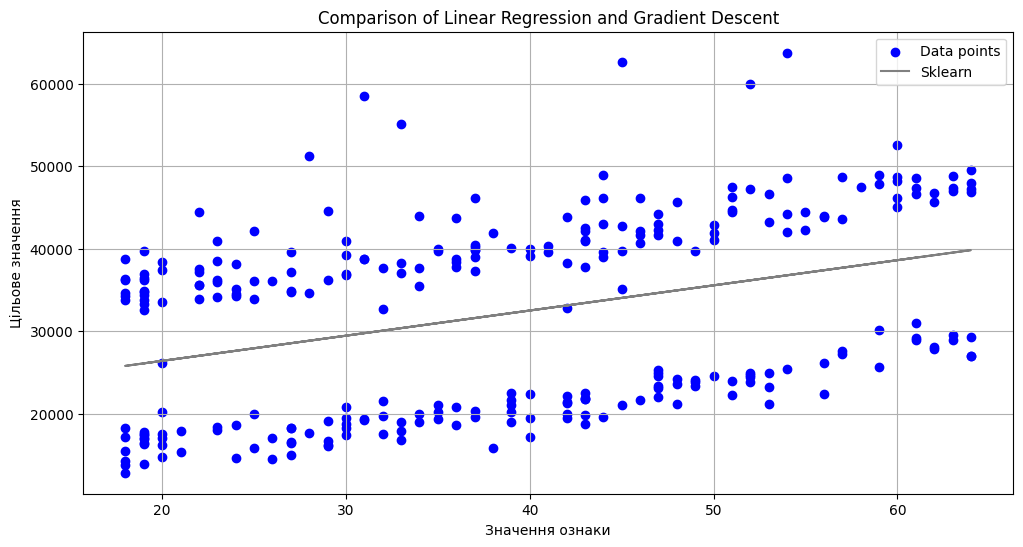

In [58]:
# Візуалізуйте модель у вигляді лінії на графіку розсіювання age проти charges

X = smoker_df['age'].values
y = smoker_df['charges'].values
plt.figure(figsize=(12, 6))
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, predictions_sklearn_1, color='grey', label='Sklearn')
plt.title('Comparison of Linear Regression and Gradient Descent')
plt.xlabel('Значення ознаки')
plt.ylabel('Цільове значення')
plt.legend()
plt.grid(True)
plt.show()



Висновки: Модель лінійної регресії для курців на основі лише одного фактору (віку) показує низьку точність. Це пояснюється тим, що витрати курців мають бімодальний розподіл (розділені на дві чіткі групи). Для покращення моделі необхідно перейти до множинної лінійної регресії